# Cost Analysis (cost_001)

96 journey configurations (2 directions x 4 speeds x 12 months) with production
hyperparameters. Multiple replicas per journey across submissions.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

sys.path.insert(0, str(Path("..").resolve()))

from load_results import (
    load_results,
    filter_kinked_routes,
    get_journey_params_df,
    get_hyper_params_df,
    get_elite_df,
    get_runtime_df,
    add_derived_features,
    filter_suspicious_routes,
)
from experiment_params import (
    REPRESENTATIVE_CASES,
    ROUTES,
)

## 1. Load & merge results

In [2]:
result_files = sorted(Path("../results").glob("cost_sub*.msgpack"))
print(f"Found {len(result_files)} result files")
for f in result_files:
    print(f"  {f.name} ({f.stat().st_size / 1e6:.1f} MB)")

Found 15 result files
  cost_sub01_20260211_163739.msgpack (3.8 MB)
  cost_sub01_20260625_102518.msgpack (5.7 MB)
  cost_sub01_20260625_163025.msgpack (5.8 MB)
  cost_sub02_20260211_164705.msgpack (3.5 MB)
  cost_sub02_20260625_102517.msgpack (5.5 MB)
  cost_sub02_20260625_163025.msgpack (5.5 MB)
  cost_sub03_20260626_121926.msgpack (1.9 MB)
  cost_sub04_20260626_121926.msgpack (2.0 MB)
  cost_sub05_20260626_121926.msgpack (1.9 MB)
  cost_sub06_20260626_121926.msgpack (1.6 MB)
  cost_sub07_20260626_121926.msgpack (1.7 MB)
  cost_sub08_20260626_121926.msgpack (1.6 MB)
  cost_sub09_20260626_121926.msgpack (1.6 MB)
  cost_sub10_20260626_121926.msgpack (1.6 MB)
  cost_sub11_20260626_121926.msgpack (1.6 MB)


In [3]:
# Load all results (dedup by key across files)
rr_dict = load_results(result_files)
print(f"Loaded {len(rr_dict)} unique results")

# Remove routes with crossover kinks (max turning angle > 60°)
rr_dict = filter_kinked_routes(rr_dict)
print(f"After kink filter: {len(rr_dict)} results")

records:   0%|          | 0/2762 [00:00<?, ?it/s]

Loaded 2762 unique results


345/2762 routes removed (max turning angle > 60.0°)
After kink filter: 2417 results


In [4]:
# Extract DataFrames
journey_df = get_journey_params_df(rr_dict)
hyper_df = get_hyper_params_df(rr_dict)
elite_df = get_elite_df(rr_dict)
runtime_df = get_runtime_df(rr_dict)

# Merge (keep only best elite per result)
elite_best = elite_df[elite_df.n_elite == 0].copy()
df = journey_df.join(hyper_df).join(elite_best).join(runtime_df)
df = add_derived_features(df)

print(f"Combined DataFrame: {len(df)} rows")
df.head()

elite:   0%|          | 0/2417 [00:00<?, ?it/s]

Combined DataFrame: 2417 rows


,journey_name,journey_lon_waypoints,journey_lat_waypoints,journey_time_start,journey_time_end,journey_speed_knots,journey_time_resolution_hours,hyper_population_size,hyper_random_seed,hyper_selection_acceptance_rate_warmup,...,elite_cost_absolute,elite_cost_relative,elite_has_negative_time,geometry,runtime,runtime_seconds,hyper_num_individuals,journey_duration,seed_cost,elite_speed_og_mps_average
filename,,,,,,,,,,,,,,,,,,,,,
result:0027:seed3284611456:hasha5f42390,Atlantic_forward,"[-80.5, -11.0]","[30.0, 50.0]",2021-03-01T00:00:00,2021-03-12T10:10:42,12.0,6.0,256,3284611456,0.3,...,6.212020e+14,0.515176,False,"LINESTRING (-80.5 29.999999999999986, -79.4551...",0 days 00:35:12,2112.0,1024,11 days 10:10:42,1.205806e+15,9.041263
result:0045:seed3819685402:hashf7802ecb,Atlantic_forward,"[-80.5, -11.0]","[30.0, 50.0]",2021-05-01T00:00:00,2021-05-12T10:10:42,12.0,6.0,256,3819685402,0.3,...,7.936281e+12,0.963040,False,"LINESTRING (-80.5 29.99999999999999, -79.50341...",0 days 00:35:30,2130.0,1024,11 days 10:10:42,8.240865e+12,6.200886
result:0047:seed2203676130:hash964debf6,Atlantic_forward,"[-80.5, -11.0]","[30.0, 50.0]",2021-05-01T00:00:00,2021-05-12T10:10:42,12.0,6.0,256,2203676130,0.3,...,7.883276e+12,0.956608,False,"LINESTRING (-80.5 29.99999999999999, -79.50657...",0 days 00:35:38,2138.0,1024,11 days 10:10:42,8.240865e+12,6.232176
result:0076:seed530259931:hash76da9615,Atlantic_forward,"[-80.5, -11.0]","[30.0, 50.0]",2021-08-01T00:00:00,2021-08-12T10:10:42,12.0,6.0,256,530259931,0.3,...,4.953289e+12,0.828524,False,"LINESTRING (-80.5 29.99999999999999, -79.48625...",0 days 00:35:57,2157.0,1024,11 days 10:10:42,5.978451e+12,6.229219
result:0036:seed1324309150:hash9ae717bb,Atlantic_forward,"[-80.5, -11.0]","[30.0, 50.0]",2021-04-01T00:00:00,2021-04-12T10:10:42,12.0,6.0,256,1324309150,0.3,...,7.652753e+12,0.885789,False,"LINESTRING (-80.5 29.99999999999999, -79.49023...",0 days 00:36:06,2166.0,1024,11 days 10:10:42,8.639474e+12,6.251522


In [5]:
# Quality filter
df_clean = filter_suspicious_routes(df)
print(f"After filtering: {len(df_clean)} / {len(df)} rows")

3.89% suspicious routes
After filtering: 2323 / 2417 rows


In [6]:
# Coverage: replicas per journey
df_clean["month"] = pd.to_datetime(df_clean.journey_time_start.astype(str)).dt.month
df_clean["direction"] = df_clean.journey_name.map(
    {"Atlantic_forward": "eastward", "Atlantic_backward": "westward"}
)
df_clean["speed"] = df_clean.journey_speed_knots.astype(float)

coverage = df_clean.groupby(["direction", "speed", "month"], observed=True).size().unstack(fill_value=0)
print("Replicas per (direction, speed, month):")
coverage

Replicas per (direction, speed, month):


month            1   2   3   4   5   6   7   8   9   10  11  12
direction speed                                                
westward  8.0    20  15  25  23  29  30  28  28  22  36  32  24
          12.0   15  14  26  20  23  25  27  22  25  21  22  22
          16.0   23  21  24  24  28  24  25  23  25  26  19  19
          20.0   30  21  23  24  24  26  23  26  29  27  22  25
eastward  8.0    21  28  27  21  30  31  22  26  30  28  23  19
          12.0    9  21  23  23  21  25  26  30  25  29  23  23
          16.0   14  26  27  24  16  25  21  24  26  25  24  27
          20.0   28  28  28  24  29  25  26  27  23  23  24  20

## 2. Cost reduction summary

In [7]:
# Cost reduction = 1 - elite_cost_relative (fraction saved vs seed route)
df_clean["cost_reduction"] = 1.0 - df_clean.elite_cost_relative

# Summary stats
print(f"Overall cost reduction: {df_clean.cost_reduction.median():.1%} median, "
      f"{df_clean.cost_reduction.mean():.1%} mean")
print(f"Range: {df_clean.cost_reduction.min():.1%} to {df_clean.cost_reduction.max():.1%}")
print()

# By direction and speed
summary = df_clean.groupby(["direction", "speed"], observed=True).cost_reduction.agg(
    ["count", "median", "mean", "std", "min", "max"]
).round(3)
summary

Overall cost reduction: 17.3% median, 41.7% mean
Range: 0.8% to 98.9%



count  median   mean    std    min    max
direction speed                                           
westward  8.0      312   0.915  0.574  0.407  0.067  0.985
          12.0     262   0.139  0.412  0.404  0.016  0.978
          16.0     281   0.103  0.310  0.354  0.008  0.930
          20.0     300   0.083  0.343  0.397  0.014  0.965
eastward  8.0      306   0.742  0.625  0.360  0.122  0.989
          12.0     278   0.158  0.279  0.229  0.010  0.978
          16.0     279   0.140  0.326  0.334  0.019  0.981
          20.0     305   0.112  0.430  0.413  0.026  0.985

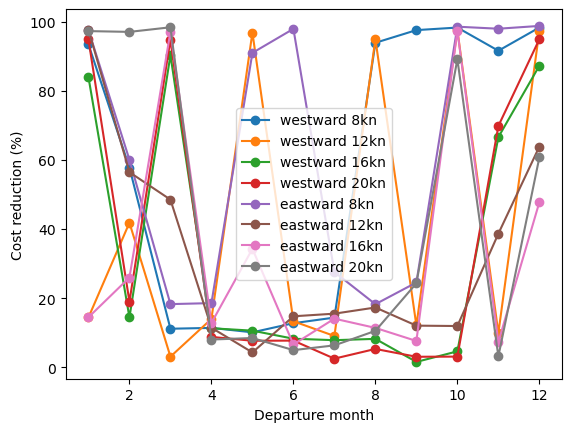

In [8]:
# Median cost reduction by month, pivoted for plotting
reduction_monthly = (
    df_clean.groupby(["direction", "speed", "month"], observed=True)
    .cost_reduction.median()
    .unstack(["direction", "speed"]) * 100
)
reduction_monthly.columns = [f"{d} {s:.0f}kn" for d, s in reduction_monthly.columns]
reduction_monthly.plot(style="o-", ylabel="Cost reduction (%)", xlabel="Departure month")
plt.show()

## 3. Cost spread per case

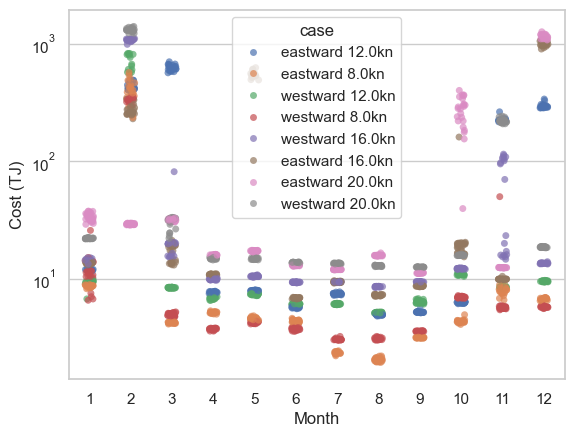

In [9]:
df_clean["cost_TJ"] = df_clean.elite_cost_absolute / 1e12
df_clean["seed_cost_TJ"] = df_clean.seed_cost / 1e12
df_clean["case"] = df_clean.direction.astype(str) + " " + df_clean.speed.astype(str) + "kn"

import seaborn as sns
sns.set_theme(style="whitegrid")
sns.stripplot(data=df_clean, x="month", y="cost_TJ", hue="case", size=5, alpha=0.7)
plt.yscale("log")
plt.ylabel("Cost (TJ)")
plt.xlabel("Month")
plt.show()

In [10]:
# Cost spread (IQR) across replicas per journey
def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

spread = df_clean.groupby(["direction", "speed", "month"], observed=True).cost_TJ.agg(
    ["median", "std", "count", iqr]
)
spread["cv"] = spread["std"] / spread["median"]  # coefficient of variation
print("Cost spread across replicas:")
print(f"  Median CV: {spread.cv.median():.3f}")
print(f"  Max CV:    {spread.cv.max():.3f}")
spread.round(4)

Cost spread across replicas:
  Median CV: 0.015
  Max CV:    1.446


median      std  count       iqr      cv
direction speed month                                             
westward  8.0   1        11.0248   4.1243     20    1.8296  0.3741
                2       327.5535  13.7460     15   15.3510  0.0420
                3         4.9576   0.1433     25    0.2434  0.0289
                4         3.7241   0.0611     23    0.0610  0.0164
                5         4.2677   0.0702     29    0.0897  0.0165
...                          ...      ...    ...       ...     ...
eastward  20.0  8        15.6901   0.1928     27    0.1543  0.0123
                9        11.1713   0.0493     23    0.0718  0.0044
                10      280.2785  83.8329     23  102.9993  0.2991
                11       12.3900   0.0358     24    0.0525  0.0029
                12     1136.6558  48.8435     20   79.5939  0.0430

[96 rows x 5 columns]

## 4. Best routes for 16 representative cases

In [11]:
# Select best route (lowest cost) per representative case
best_keys = {}
for ci, case in enumerate(REPRESENTATIVE_CASES):
    route_name = case["route"]
    month = case["month"]
    speed = case["speed"]

    mask = (
        (df_clean.journey_name == route_name)
        & (df_clean.month == month)
        & (df_clean.speed == speed)
    )
    sub = df_clean[mask].sort_values("elite_cost_absolute")
    if len(sub) == 0:
        print(f"Case {ci}: NO RESULTS for {route_name} month={month} speed={speed}")
        continue

    best_key = sub.index[0]
    best_keys[ci] = best_key
    cost_TJ = sub.iloc[0].cost_TJ
    reduction = sub.iloc[0].cost_reduction
    n_replicas = mask.sum()
    print(f"Case {ci}: {route_name} month={month} {speed}kn "
          f"-> {cost_TJ:.3f} TJ ({reduction:.1%} reduction, {n_replicas} replicas)")

Case 0: Atlantic_forward month=8 8.0kn -> 1.935 TJ (22.7% reduction, 26 replicas)
Case 1: Atlantic_forward month=8 12.0kn -> 4.795 TJ (19.8% reduction, 30 replicas)
Case 2: Atlantic_forward month=8 16.0kn -> 7.065 TJ (13.4% reduction, 24 replicas)
Case 3: Atlantic_forward month=8 20.0kn -> 15.554 TJ (11.3% reduction, 27 replicas)
Case 4: Atlantic_backward month=8 8.0kn -> 2.994 TJ (94.2% reduction, 28 replicas)
Case 5: Atlantic_backward month=8 12.0kn -> 5.066 TJ (95.2% reduction, 22 replicas)
Case 6: Atlantic_backward month=8 16.0kn -> 8.404 TJ (9.6% reduction, 23 replicas)
Case 7: Atlantic_backward month=8 20.0kn -> 12.635 TJ (7.0% reduction, 26 replicas)
Case 8: Atlantic_forward month=1 8.0kn -> 8.198 TJ (97.8% reduction, 21 replicas)
Case 9: Atlantic_forward month=1 12.0kn -> 11.654 TJ (97.8% reduction, 9 replicas)
Case 10: Atlantic_forward month=1 16.0kn -> 13.197 TJ (16.2% reduction, 14 replicas)
Case 11: Atlantic_forward month=1 20.0kn -> 28.939 TJ (97.7% reduction, 28 replicas)

In [12]:
# Extract best RoutingResults for downstream figure generation
best_results = {ci: rr_dict[key] for ci, key in best_keys.items()}
print(f"Best results extracted for {len(best_results)} / {len(REPRESENTATIVE_CASES)} representative cases")

Best results extracted for 16 / 16 representative cases


## 5. Runtime overview

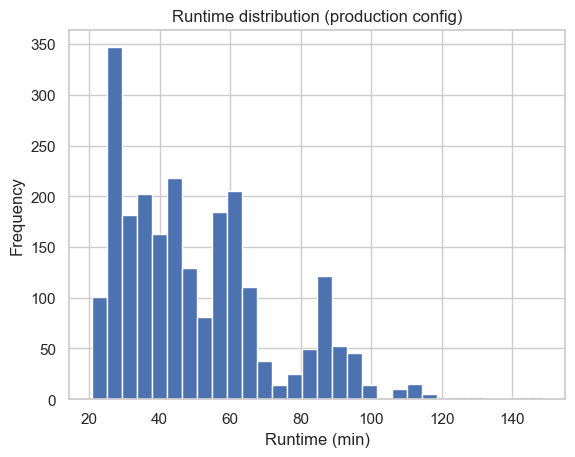

In [13]:
df_clean.runtime_seconds.div(60).plot.hist(bins=30)
plt.xlabel("Runtime (min)")
plt.title("Runtime distribution (production config)")
plt.show()